### Example: Zero-shot prediction of DNA mutation effects using Mistral-DNA
*This tutorial is based on some fantastic materials created by Prof. Raphael Mourad at the University Paul Sabatier in Toulouse, France. You can find the full tutorial and lecture notes in his GitHub repository here: https://github.com/raphaelmourad/LLM-for-genomics-training.*

First, let's clone the GitHub repository for the model:

In [ ]:
!git clone https://github.com/raphaelmourad/Mistral-DNA.git

Cloning into 'Mistral-DNA'...
remote: Enumerating objects: 338, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 338 (delta 29), reused 31 (delta 5), pack-reused 235 (from 1)
Receiving objects: 100% (338/338), 112.78 MiB | 17.14 MiB/s, done.
Resolving deltas: 100% (102/102), done.
Updating files: 100% (63/63), done.


Then, we need to install and import the required libraries.

In [5]:
!pip install "transformers==4.36.0" --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [1]:
!pip install Bio==1.7.1 --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.0 MB/s eta 0:00:00


In [2]:
# Import required libraries
import torch
import tensorflow as tf
import numpy as np
import scipy as sp

import gzip
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer
from transformers import AutoModelForMaskedLM, AutoModelForCausalLM, AutoConfig

#### Helper functions
Let's define a few helper functions to aid with the task.

In [ ]:
# Function to read FASTA files
def readRegularFastaFile(fasta_file):
	seql_list=[]
	with gzip.open(fasta_file, "rt") as handle:
			for record in SeqIO.parse(handle, "fasta"):
					seqj=str(record.seq)
					seql_list.append(seqj)

	return seql_list

Now we need to load the model and tokeniser.

In [ ]:
# Define our model path: https://huggingface.co/RaphaelMourad/Mistral-DNA-v1-17M-hg38
MODEL_PATH = "RaphaelMourad/Mistral-DNA-v1-17M-hg38"

In [ ]:
# LOAD TOKENIZER
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    padding_side="left", # Here, the model was trained with padding_side="left"
    use_fast=True,
    trust_remote_code=True,
)
#tokenizer.eos_token='[EOS]'
#tokenizer.pad_token = '[PAD]'

config.json:   0%|          | 0.00/793 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/168k [00:00<?, ?B/s]

In [ ]:
# LOAD MODEL
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
)
model.config.pad_token_id = tokenizer.pad_token_id
model

model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

MixtralForCausalLM(
  (model): MixtralModel(
    (embed_tokens): Embedding(4096, 256)
    (layers): ModuleList(
      (0-7): 8 x MixtralDecoderLayer(
        (self_attn): MixtralAttention(
          (q_proj): Linear(in_features=256, out_features=256, bias=False)
          (k_proj): Linear(in_features=256, out_features=256, bias=False)
          (v_proj): Linear(in_features=256, out_features=256, bias=False)
          (o_proj): Linear(in_features=256, out_features=256, bias=False)
        )
        (mlp): MixtralSparseMoeBlock(
          (gate): MixtralTopKRouter()
          (experts): MixtralExperts(
            (act_fn): SiLUActivation()
          )
        )
        (input_layernorm): MixtralRMSNorm((256,), eps=1e-05)
        (post_attention_layernorm): MixtralRMSNorm((256,), eps=1e-05)
      )
    )
    (norm): MixtralRMSNorm((256,), eps=1e-05)
    (rotary_emb): MixtralRotaryEmbedding()
  )
  (lm_head): Linear(in_features=256, out_features=4096, bias=False)
)

In [ ]:
# NUMBER OF MODEL PARAMETERS
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(f"Model size: {pytorch_total_params/1000**2:.1f}M parameters")

Model size: 16.8M parameters


#### Compute sequence embeddings
For a model to be able to process a sequence, it must be converted into a vector of numbers. These vectors are called *embeddings*.

More information on LLM embeddings: https://huggingface.co/spaces/hesamation/primer-llm-embedding?section=what_are_embeddings?

Let's generate the embeddings for a sample DNA sequence.

In [ ]:
dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC" # Our sample DNA sequence

inputs = tokenizer(dna, return_tensors = 'pt')["input_ids"]
print(f"Inputs: {inputs}")

hidden_states = model(inputs)[0].detach()
print(f"Hidden states: {hidden_states}")

# Embedding with mean pooling
embedding_mean = torch.mean(hidden_states[0], dim=0)
print(f"Shape of embedding with mean pooling: {embedding_mean.shape}")

# Embedding with max pooling
embedding_max = torch.max(hidden_states[0], dim=0)[0]
print(f"Shape of embedding with max pooling: {embedding_max.shape}")

Inputs: tensor([[   1,    5,  194,   32,  757, 1239, 2092,  294,   24,  359,   88,   93,
           32,   75,   77,   19,    2]])
Hidden states: tensor([[[-5.7812, -2.6875,  0.1953,  ..., -0.8359, -0.4297, -2.4375],
         [-5.9062, -3.0625, -1.7734,  ..., -0.4551, -0.2617, -1.7891],
         [-6.4062, -3.5156, -0.8828,  ..., -0.4805, -0.2295, -1.4453],
         ...,
         [-6.7188, -4.0312, -0.3242,  ...,  0.0879,  0.0413, -1.0781],
         [-4.1875, -0.5469,  7.8750,  ..., -1.6641, -5.4375, -4.1562],
         [-6.6250, -4.2812, -0.0212,  ..., -0.2520, -2.3906, -0.3594]]],
       dtype=torch.bfloat16)
Shape of embedding with mean pooling: torch.Size([4096])
Shape of embedding with max pooling: torch.Size([4096])


#### Compute cystic fibrosis mutation effect (Gene: CFTR)
1. Get the wild-type and mutated versions of the sample sequence
2. Tokenise both sequences
3. Get the hidden states of the sequences
4. Calculate the embeddings from the hidden states
5. Get the L2 distance between the embeddings of the wild-type and mutated sequences -> this is the (unnormalised) mutation effect

**Case 1: Impactful mutation**

In [ ]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT"
dna_mut="ATTAAAGAAAATATCATTGGTGTTTCCTAT" # The mutation here is the deletion of CTTT

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach()

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalised)

tensor([[-5.6562, -2.4062,  5.1562,  ...,  1.9453,  1.5000,  3.8906],
        [-2.0625,  0.7734,  4.8750,  ...,  1.6172,  1.4531,  1.1875]],
       dtype=torch.bfloat16)
tensor(148., dtype=torch.bfloat16)


**Case 2: Non-impactful mutation**

In [ ]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATT = Isoleucine
dna_mut="ATAAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATA = Isoleucine

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach() # [1, sequence_length, 768]

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalised)

tensor([[-5.6562, -2.4062,  5.1562,  ...,  1.9453,  1.5000,  3.8906],
        [-5.5312, -2.3281,  4.9688,  ...,  1.9375,  1.7422,  3.8281]],
       dtype=torch.bfloat16)
tensor(26.8750, dtype=torch.bfloat16)


We can see that the impactful mutation produces a higher value than the non-impactful mutation, i.e., higher impact == higher mutation effect score.

#### Compute and compare the impacts of SNPs in introns vs exons

In [ ]:
# Load all SNPs
file_SNPexon_ref="Mistral-DNA/data/SNP/SNPexon_ref_201b.fasta.gz"
file_SNPexon_alt="Mistral-DNA/data/SNP/SNPexon_alt_201b.fasta.gz"
file_SNPintron_ref="Mistral-DNA/data/SNP/SNPintron_ref_201b.fasta.gz"
file_SNPintron_alt="Mistral-DNA/data/SNP/SNPintron_alt_201b.fasta.gz"

# Let's use sequences of length 100 to speed things up
kseq=100
exon_ref_seq=readRegularFastaFile(file_SNPexon_ref)[0:kseq]
exon_alt_seq=readRegularFastaFile(file_SNPexon_alt)[0:kseq]
intron_ref_seq=readRegularFastaFile(file_SNPintron_ref)[0:kseq]
intron_alt_seq=readRegularFastaFile(file_SNPintron_alt)[0:kseq]

Let's define a function to compute the embeddings of the DNA sequences.

In [ ]:
def compEmbed(seq_list): # Input: list of sequences
  inputs_seqs = tokenizer(seq_list, return_tensors = 'pt', padding=True)["input_ids"] # Tokenise the input sequences
  hidden_states_seqs = model(inputs_seqs)[0].detach().cpu().float().numpy() # Get the hidden states
  embedding_max = np.max(hidden_states_seqs, axis=1) # Embedding with max pooling
  return embedding_max

Then, we can use this to define a function to compute the mutation effect.

In [ ]:
def compMutEffect(seq_ref_list,seq_alt_list): # Input: list of wild-type sequences and list of mutated sequences
  embedding_ref = compEmbed(seq_ref_list) # Compute the embeddings of the wild-type sequences
  embedding_alt = compEmbed(seq_alt_list) # Compute the embeddings of the mutated sequences
  distL2 = np.linalg.norm(embedding_alt -embedding_ref, axis=1, ord=2) # Calculate the L2 distances between the embeddings
  return distL2

We will now use this function to calculate the effects of all SNPs in the exons and introns.

In [ ]:
distL2_exonSNPs = compMutEffect(exon_ref_seq, exon_alt_seq) # Compute exon SNP effects
distL2_intronSNPs = compMutEffect(intron_ref_seq, intron_alt_seq) # Compute intron SNP effects

Let's create a boxplot of the distributions of exon vs intron SNP effects.

/tmp/ipykernel_3275/3869896662.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(distL2SNPs.keys())


Text(0, 0.5, 'L2 Distance')

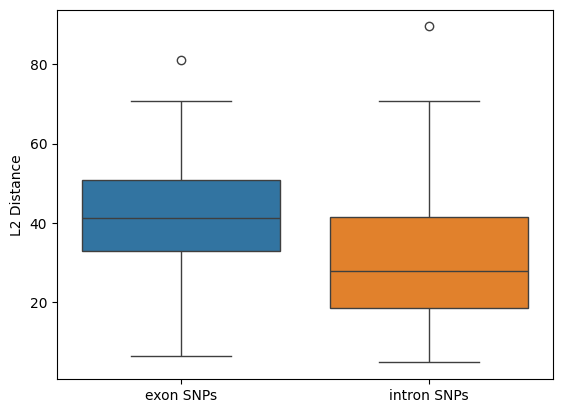

In [ ]:
distL2SNPs = {'exon SNPs': distL2_exonSNPs, 'intron SNPs': distL2_intronSNPs}

fig, ax = plt.subplots()
sns.boxplot(ax=ax, data=distL2SNPs)
ax.set_xticklabels(distL2SNPs.keys())
ax.set_ylabel("L2 Distance")

We see that the L2 distance is higher for SNPs in exons compared to SNPs in introns. This is expected, as SNPs in exons are expected to have a greater impact.

Refresher on exons and introns: https://dnalc.cshl.edu/view/15549-Transcription-translation-Exons-and-introns.html, https://www.cd-genomics.com/blog/introns-and-exons/.

### Try it yourself: Zero-shot prediction of mutation effects using Nucleotide Transformer

In [3]:
MODEL_NAME = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME, trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

In [ ]:
# Load tokeniser
tokenizer = # Your code here

##### Solution

In [4]:
# Load tokeniser
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    padding_side="left", # Here, the model was trained with padding_side="left"
    use_fast=True,
    trust_remote_code=True,
)

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

#### Compute cystic fibrosis mutation effect (Gene: CFTR)
1. Get the wild-type and mutated versions of the sample sequence
2. Tokenise both sequences
3. Get the hidden states of the sequences
4. Calculate the embeddings from the hidden states
5. Get the L2 distance between the embeddings of the wild-type and mutated sequences -> this is the (unnormalised) mutation effect

##### **Case 1: Impactful mutation**

In [ ]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT"
dna_mut="ATTAAAGAAAATATCATTGGTGTTTCCTAT" # The mutation here is the deletion of CTTT

inputs_seqs = # Your code here
hidden_states_seqs = model(inputs_seqs)[0].detach()

embedding_max = # Your code here
print(embedding_max)

distL2 = # Your code here
print(distL2) # Mutation effect (unnormalised)

###### Solution

In [5]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT"
dna_mut="ATTAAAGAAAATATCATTGGTGTTTCCTAT" # The mutation here is the deletion of CTTT

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach()

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalised)

tensor([[-9.2201, -9.6858, -9.8567,  ..., 12.1464, 15.9689, 14.5510],
        [-9.8340, -9.2863, -9.3982,  ..., -0.3090,  0.9604,  4.2570]])
tensor(178.2122)


##### **Case 2: Non-impactful mutation**

In [ ]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATT = Isoleucine
dna_mut="ATAAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATA = Isoleucine

inputs_seqs = # Your code here
hidden_states_seqs = model(inputs_seqs)[0].detach() # [1, sequence_length, 768]

embedding_max = # Your code here
print(embedding_max)

distL2 = # Your code here
print(distL2) # Mutation effect (unnormalised)

###### Solution

In [6]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATT = Isoleucine
dna_mut="ATAAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATA = Isoleucine

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach() # [1, sequence_length, 768]

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalised)

tensor([[-9.2201, -9.6858, -9.8567,  ..., 12.1464, 15.9689, 14.5510],
        [-9.7009, -9.7375, -9.3364,  ..., 12.7865, 15.8241, 14.8497]])
tensor(62.2222)


##### **What do you notice about the difference in the L2 norm for the impactful vs non-impactful mutation?**